# Observer

Het observer pattern definieert een één-op-veel afhankelijkheid tussen objecten zodat wanneer één object verandert (de subject) van toestand verandert, alle afhankelijke objecten (de observers) op de hoogte worden gesteld en automatisch worden bijgewerkt.

&rarr; Wordt veel gebruikt in systemen die realtime updates vereisen, zoals GUI's en event-driven systemen.

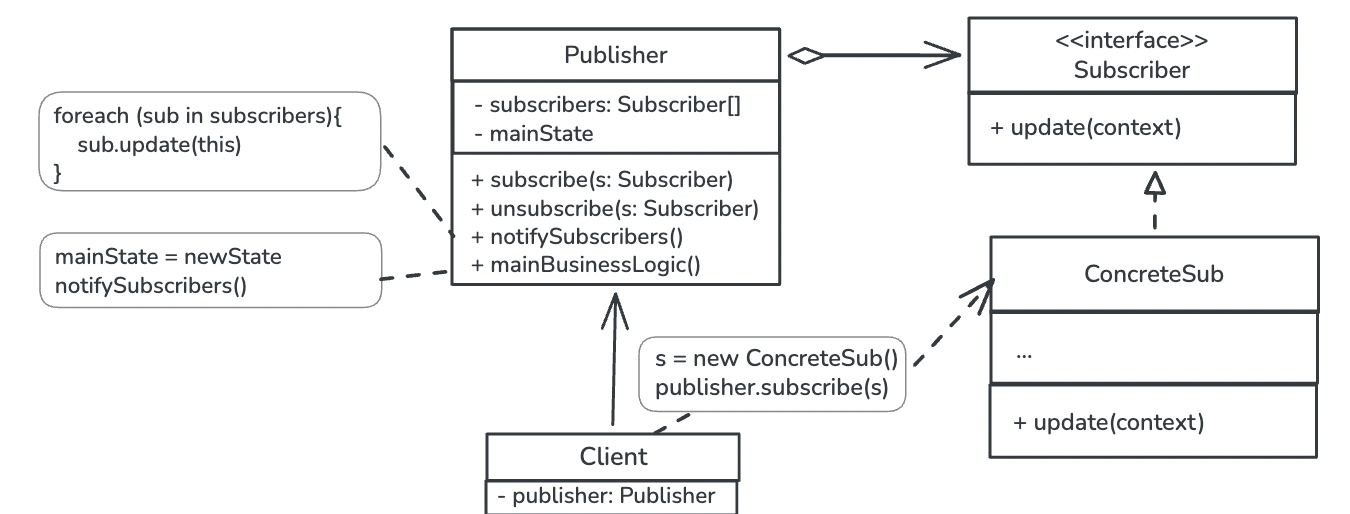

In [ ]:
//* De observable
class WeatherStation {
    private temperature: number;
    private observers: Observer[] = [];


    public setTemperature(temp: number): void {
        this.temperature = temp;
        this.notifyObservers();
    }

    public getTemperature(): number {
        return this.temperature;
    }

    public addObserver(observer: Observer): void {
        this.observers.push(observer);
    }

    public removeObserver(observer: Observer): void {
        const index = this.observers.indexOf(observer);
        if (index > -1) {
            this.observers.splice(index, 1);
        }
    }

    private notifyObservers(): void {
        for (const observer of this.observers) {
            observer.update(this.temperature);
        }
    }
}

interface Observer {
    update(temperature: number): void;
}

class TemperatureDisplay implements Observer {
    public update(temperature: number): void {
        console.log(`Temperature Display: The current temperature is ${temperature}°C`);
    }
}

class TemperatureLogger implements Observer {
    public update(temperature: number): void {
        console.log(`Temperature Logger: Logging temperature ${temperature}°C`);
    }
}

const weatherStation = new WeatherStation();
const display = new TemperatureDisplay();
const logger = new TemperatureLogger();

weatherStation.addObserver(display);
weatherStation.addObserver(logger);

weatherStation.setTemperature(25);
weatherStation.setTemperature(30);

Temperature Display: The current temperature is 25°C
Temperature Logger: Logging temperature 25°C
Temperature Display: The current temperature is 30°C
Temperature Logger: Logging temperature 30°C
